**Project Title:** Mental Health Text Classifier
**Project Type:** Practice Focused to build an application
  
### Group Members:  
*  Alvin Boakai (asb424@drexel.edu)
*  Maya Gallardo (Mg3957@drexel.edu)
*  Shad Scarboro (srs359@drexel.edu)

# **Project Overview:**
This project aimed to address the challenge of assessing and identifying potential mental health conditions reflected in random unstructured text message. The goal was to develop a web-based application that accepts a block of text and applies a classification model to analyze the contextual pattern in the text and predicts which of the four categories it most closely represents: anxiety, depression, suicidal, or normal.  This was successful.



### **Model and Tools**:
Our goal was to build an AI model capable of analyzing text and predicting a likely mental health category for each input statement. To achieve this, we implemented a supervised text classification pipeline that takes unstructured sentences as input and outputs one of the four mental health labels.

The pipeline:
Data -> Preprocessing -> Vectorization -> Model -> Training -> Prediction​

For this effort, we implemented a Naive Bayes Classifier and a Neural Network Classifier.

#### **We used the following AI tools and libraries:**
* *TensorFlow* for building and training deep learning–based text classifiers.
* *Scikit-learn* (SK Learn) for traditional machine learning baselines, preprocessing utilities, and evaluation metrics.
* *Streamlit* to create an interactive web interface where users can type or paste text and receive a predicted mental health category.
* *GitHub* for version control, collaboration, and storing code, notebooks, and documentation.

### **System Functionality:**
To demonstrate the use of this data, we created a website that allows a user to paste in text and then recieve a mental health classification.  The final system performs the following steps for a user’s text input: 
1. Accepts an unstructured statement through the Streamlit interface. 
2. Applies the same preprocessing used during training (tokenization, vectorization). 
3. Feeds the processed text into the indicated model. 
4. Outputs a predicted mental health category: Anxiety, Depression, Suicidal, or Normal.

You can view the application here: [Mental Health Classifier](https://info-629-mental-health-classifier.streamlit.app/)

## Intended Impact:
The project demonstrates how AI can assist in early screening of potential mental health concerns based on language patterns in text. While it is not a diagnostic tool, it can support awareness, guide further assessment, and showcase the potential of applied AI in mental health-related applications.

## **Potential Beneficiaries** 
The following groups are potential beneficiaries of this project or something similair:

**The Nationa Alliance on Mental Illness (NAMI)**, the largest grassroots mental health organization in the USA, advocates and provide resources to mental health patients. 

The NAMI uses social media to gather and research findings, funding opportunities, and information on mental health illnesses.  This tool could facilitate the automation and processing of gathered data.

**To Write Love on Her Arms (TWLOHA)**, a nonprofit organization that focuses on supporting people struggling with depression, addition, self-inhury, and suicide. This Project provides analytical researched data of evidence of mental health concerns generated from social media. 

TWLOHA provides analytical researched data of evidence of mental health concerns generated from social media. This tool would enable these organizations to provide early intervention, create awareness, and provide treatments and counseling.

## Full code
The full body of our code can be found on GitHub: [INFO-629-Mental-Health-Classifier](https://github.com/TheCSpider/INFO-629-Mental-Health-Classifier)

## **Data and Preprocessing**
We collected mental health–related datasets from Kaggle and merged them into a single, unified dataset using Python.
* [Mental Health Prediction](https://www.kaggle.com/datasets/footsurebead/mental-status)
* [Mental Health Text Classification Dataset](https://www.kaggle.com/datasets/priyangshumukherjee/mental-health-text-classification-dataset/data)

The raw data contained both structured features (e.g., demographics, social media usage) and unstructured text, so we focused on cleaning and formatting the text and labels into a consistent, model-ready file.



In [2]:
import pandas as pd
import os

print("Current working directory:")
print(os.getcwd())

# ---------------------------------
# Load the first dataset
# ---------------------------------
data1 = pd.read_csv("data/mental_health_prediction/cleanData.csv")
data1 = data1.drop(columns=['index'])  # Drop the unnecessary index column
print("Data1 status: ", data1['status'].unique())

# ---------------------------------
# Load the second dataset
# ---------------------------------
data2 = pd.read_csv("data/mental_health_text_classification_dataset/mental_health_unbalanced.csv")
data2 = data2.drop(columns=['Unique_ID'])  # Drop the unnecessary Unique_ID column
data2 = data2.rename(columns={'text': 'statement'})  # Rename columns to match data1
print("Data2 status: ", data2['status'].unique())


# Remove the extra status values from data1 to match data2
data1 = data1[data1['status'].isin(data2['status'].unique())]

print("----------------------------------")
print("Data1 status: ", data1['status'].unique())
print("Data2 status: ", data2['status'].unique())
print("----------------------------------")

# ----------------------------------------------------
# Combine the two datasets and save to a new CSV file
# ----------------------------------------------------
combined = pd.concat([data1, data2])

print("Combined shape:", combined.shape)
combined.drop_duplicates()
print("Combined shape after dropping duplicates:", combined.shape)

# Make everything lower case and strip whitespace for the statement column
combined["statement"] = combined["statement"].astype(str).str.lower().str.strip()

combined.to_csv("processed/combined.csv", index=False)

print("Done merging!")


Current working directory:
/home/shadrs/git/INFO-629/INFO-629-Mental-Health-Classifier
Data1 status:  <ArrowStringArray>
[             'Anxiety',               'Normal',           'Depression',
             'Suicidal',               'Stress',              'Bipolar',
 'Personality disorder']
Length: 7, dtype: str
Data2 status:  <ArrowStringArray>
['Anxiety', 'Normal', 'Depression', 'Suicidal']
Length: 4, dtype: str
----------------------------------
Data1 status:  <ArrowStringArray>
['Anxiety', 'Normal', 'Depression', 'Suicidal']
Length: 4, dtype: str
Data2 status:  <ArrowStringArray>
['Anxiety', 'Normal', 'Depression', 'Suicidal']
Length: 4, dtype: str
----------------------------------
Combined shape: (95851, 2)
Combined shape after dropping duplicates: (95851, 2)
Done merging!


## **Naive Bayes Model**
The first classifier approach we used was a Naïve Bayes classifier.  It is commonly used for text classification tasks.




In [3]:
# -------------------------------------
# Load the CSV Data and summarize it
# -------------------------------------
import pandas as pd
import numpy as np

# Load the CSV file into a DataFrame
data = pd.read_csv('./processed/combined.csv')

# -------------------------------------
# Split the data into training and testing sets: 80/20 split
# -------------------------------------
# Set a random seed for reproducibility so that the comments on the set don't need to be changed when the code is run again
random_seed = 2142026
np.random.seed(random_seed)

# generate random true (80% chance) or false values
train_index = np.random.rand(len(data)) < 0.8

# use the above list to take the training (true values)
train = data[train_index]
# the opposite (rest) is for testing
test = data[~train_index]

print(train[:5])


# -------------------------------------
# Make a list of the statuses for use later
# -------------------------------------
statuses = data['status'].unique()
print(f"\nStatuses: {statuses}")

                                           statement   status
0                                         oh my gosh  Anxiety
1  trouble sleeping, confused mind, restless hear...  Anxiety
2  all wrong, back off dear, forward doubt. stay ...  Anxiety
3  i've shifted my focus to something else but i'...  Anxiety
5  every break, you must be nervous, like somethi...  Anxiety

Statuses: <ArrowStringArray>
['Anxiety', 'Normal', 'Depression', 'Suicidal']
Length: 4, dtype: str


### **Class distribution and Probabilities**

In [4]:
def profile_statuses(data):
    # Count instances of each unique value in the 'status' column
    status_counts = data['status'].value_counts()

    # print(status_counts)

    print(f"Total statements: {len(data)}")
    for status in statuses:
        count = status_counts[status]
        prob_of_status = count / len(data)
        print(f"Status: {status}, Count: {count}, Probability: {prob_of_status:.2f}")

print("\nOverall Status Distribution:")
profile_statuses(data)
print("\nTraining Set Status Distribution:")
profile_statuses(train)
print("\nTesting Set Status Distribution:")
profile_statuses(test)


Overall Status Distribution:
Total statements: 95851
Status: Anxiety, Count: 9344, Probability: 0.10
Status: Normal, Count: 34734, Probability: 0.36
Status: Depression, Count: 29910, Probability: 0.31
Status: Suicidal, Count: 21863, Probability: 0.23

Training Set Status Distribution:
Total statements: 76709
Status: Anxiety, Count: 7462, Probability: 0.10
Status: Normal, Count: 27801, Probability: 0.36
Status: Depression, Count: 23938, Probability: 0.31
Status: Suicidal, Count: 17508, Probability: 0.23

Testing Set Status Distribution:
Total statements: 19142
Status: Anxiety, Count: 1882, Probability: 0.10
Status: Normal, Count: 6933, Probability: 0.36
Status: Depression, Count: 5972, Probability: 0.31
Status: Suicidal, Count: 4355, Probability: 0.23


### **Term Probabilities**

In [5]:
import math
import matplotlib.pyplot as plt
from matplotlib import animation, rc
import pandas as pd
from IPython.display import HTML, display
from sklearn.feature_extraction.text import CountVectorizer

plt.rcdefaults()

# instantiate a count vectorizer
vect = CountVectorizer(stop_words='english')

# obtain vocabulary dictionary and return doc-term matrix
X = vect.fit_transform(train.statement)

# get the identified terms
terms = vect.get_feature_names_out()
# terms = vect.get_feature_names()

# sum terms' frequencies in the entire collection
freqs = X.toarray().sum(axis=0)
terms = np.array(terms)
freqs = np.array(freqs)

# organize the tersm and frequencies in t and f columns
tfs = pd.DataFrame({'t':terms, 'f':freqs}, columns=['t','f'])

tfs = tfs.sort_values(by=['f'], ascending=False)
tfs = tfs.reset_index(drop=True)

In [6]:
# Show the top 10 most frequent terms
tfs['k'] = tfs.index + 1
tfs[['t','k','f']].head(5)

,t,k,f
0,just,1,61945
1,like,2,46151
2,feel,3,38569
3,want,4,35690
4,life,5,29313


### Plot a Linear Regression of the data rank and probability

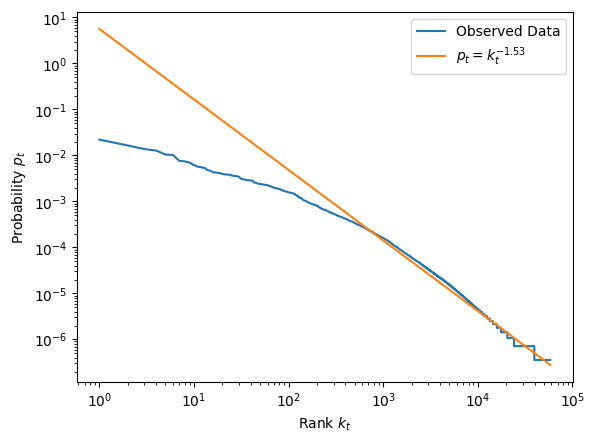

In [ ]:
from sklearn.linear_model import LinearRegression
tfs['k'] = tfs.index + 1

ttf = tfs['f'].sum()
tfs['p'] = tfs['f'] / ttf

# log transformation of k and p values
x = tfs['k'].values.reshape(-1,1)
xlog = np.log(x)
y = tfs['p'].values.reshape(-1,1)
ylog = np.log(y)

# perform linear regression on log values
lm = LinearRegression()
lm.fit(xlog,ylog)
yplog = lm.predict(xlog)

# plot the fitted (predicted) line
# along with actual k_t and p_t data
plt.loglog(tfs['k'], tfs['p'], label="Observed Data")
plt.loglog(x, np.exp(yplog),
           label="$p_t = k_t^{" + "{:.2f}".format(lm.coef_[0][0]) + "}$")
plt.xlabel('Rank $k_t$')
plt.ylabel('Probability $p_t$')
plt.legend()
plt.show()

### **Text Vectorization**

In [7]:
# instantiate a count vectorizer
test_vect = CountVectorizer(stop_words='english')

train_fit_transform = test_vect.fit_transform(train.statement)

features = test_vect.get_feature_names_out()
print(features[:10])

test_transform = test_vect.transform(test.statement)
features_test = test_vect.get_feature_names_out()
print(features_test[:10])

['00' '000' '0000' '00000' '000000' '000000000' '00000062' '000002'
 '00001' '0001']
['00' '000' '0000' '00000' '000000' '000000000' '00000062' '000002'
 '00001' '0001']


### **Construct Probabilistic Naive Bayes Model**

Using SKLearn's GridSearchCV function to find the best Alpha value to use with this dataset.

In [15]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV


# Make use of GridSearch to find the best alpha value for the Naive Bayes classifier
param_grid = {'alpha': [0.0001, 0.0005, 0.001, 0.0015, 0.01, 0.05, 0.1, 0.15, 0.5, 0.9, 1.0, 1.5, 2.0]}

grid_search = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=6,
    n_jobs=-1
)
grid_search.fit(train_fit_transform, train.status)

print(f"Best alpha: {grid_search.best_params_['alpha']}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best alpha: 0.001
Best cross-validation accuracy: 0.7544


The accuracy (75.4%) is not as good as we would like.  However, it is likely the best we can manage with this data set and this classifier.

In [16]:
alpha = 0.001
bnb = MultinomialNB(alpha=alpha)
bnb.fit(train_fit_transform, train.status)
v1p = bnb.predict(test_transform)
print(v1p[:10])

['Anxiety' 'Depression' 'Depression' 'Anxiety' 'Anxiety' 'Anxiety'
 'Anxiety' 'Anxiety' 'Anxiety' 'Depression']


### Create a Confusion Matrix for the Naive Bayes Classifier

['Anxiety' 'Depression' 'Depression' 'Anxiety' 'Anxiety' 'Anxiety'
 'Anxiety' 'Anxiety' 'Anxiety' 'Depression']


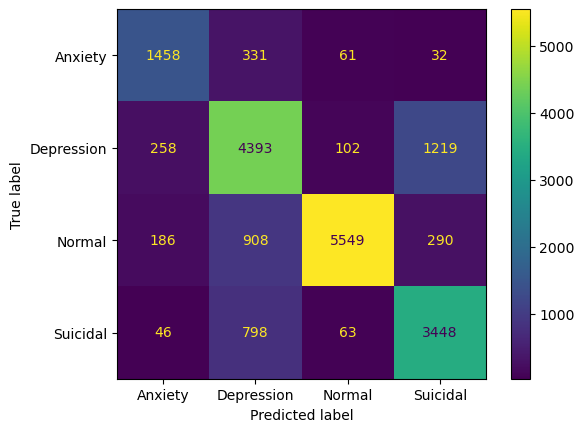

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
test_predict = bnb.predict(test_transform)
print(test_predict[:10])

ConfusionMatrixDisplay.from_predictions(test.status,
                                        test_predict,
                                        display_labels=bnb.classes_)

The confusion matrix shows us that the biggest source of error is texts values that are classified in the training set as Depression, being labeled as Suicidal by our classifier.  Followed by Normals being classified erroneously as Depression.

In [12]:
for status in statuses:
    predicted_count = np.sum(test_predict == status)
    actual_count = np.sum(test.status == status)
    false_predictions = np.sum((test.status == status) & (test_predict != status))
    print(f"Status: {status}, Predicted Count: {predicted_count}, Actual Count: {actual_count}")

    percent_false_predictions = (false_predictions/predicted_count) * 100
    print(f"    Percent of false predictions for {status}: {percent_false_predictions:.2f}%")

    for status2 in statuses:
        count = np.sum((test.status == status) & (test_predict == status2))
        print(f"    Predicted as {status2}: {count}")

Status: Anxiety, Predicted Count: 1954, Actual Count: 1882
    Percent of false predictions for Anxiety: 21.60%
    Predicted as Anxiety: 1460
    Predicted as Normal: 61
    Predicted as Depression: 329
    Predicted as Suicidal: 32
Status: Normal, Predicted Count: 5781, Actual Count: 6933
    Percent of false predictions for Normal: 23.92%
    Predicted as Anxiety: 189
    Predicted as Normal: 5550
    Predicted as Depression: 906
    Predicted as Suicidal: 288
Status: Depression, Predicted Count: 6415, Actual Count: 5972
    Percent of false predictions for Depression: 24.71%
    Predicted as Anxiety: 258
    Predicted as Normal: 106
    Predicted as Depression: 4387
    Predicted as Suicidal: 1221
Status: Suicidal, Predicted Count: 4992, Actual Count: 4355
    Percent of false predictions for Suicidal: 18.11%
    Predicted as Anxiety: 47
    Predicted as Normal: 64
    Predicted as Depression: 793
    Predicted as Suicidal: 3451


In [33]:
from sklearn.metrics import accuracy_score, cohen_kappa_score
acc = accuracy_score(v1p, test.status)
kappa = cohen_kappa_score(v1p, test.status)

print("Accuracy: {:.4f}".format(acc))
print("Kappa   : {:.4f}".format(kappa))


Accuracy: 0.7757
Kappa   : 0.6870


#### **Pickle the Naive Bayes model**
This way the model may be used in other places, whether is our simple website or somewhere else.


In [18]:
import pickle

# Save the model to a file
with open('naive_bayes/naive_bayes_model.pkl', 'wb') as file:
    pickle.dump(bnb, file)

### **Construct Probabilistic Neural Network Model**
Our second approach was to create a Neural Network model.  This was done by making use of TensorFlow's deep learning model, that allows for dense layers for classification, and label encoding for output categories.

In [19]:
import pandas as pd
import numpy as np
import tensorflow as tf
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder

I0000 00:00:1773968074.265943   26417 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773968075.056191   26417 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773968077.461891   26417 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [20]:
df = pd.read_csv("processed/combined.csv")
df= df[["statement", "status"]]
df = df.dropna()

df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"all wrong, back off dear, forward doubt. stay ...",Anxiety
3,i've shifted my focus to something else but i'...,Anxiety
4,"i'm restless and restless, it's been a month n...",Anxiety


In [21]:
df["status"].value_counts()

status
Normal        34734
Depression    29910
Suicidal      21863
Anxiety        9344
Name: count, dtype: int64

#### Create the Label Encoder and Vectorize the text

In [25]:
encoder = LabelEncoder()
y = encoder.fit_transform(df["status"])

vectorizer = CountVectorizer(max_features=2000)
X = vectorizer.fit_transform(df["statement"]).toarray()

#### Split the data into Training and Testing datasets

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Create the untrained model

In [26]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(np.unique(y)), activation='softmax')
])

E0000 00:00:1773968340.010574   26417 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773968340.011119   38106 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773968340.037450   26417 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


#### Configure the optimizer
This will search the solution space and optimize the model for accuracy.

In [29]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8929 - loss: 0.2774 - val_accuracy: 0.8631 - val_loss: 0.3987
Epoch 2/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9037 - loss: 0.2563 - val_accuracy: 0.8669 - val_loss: 0.3911
Epoch 3/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9121 - loss: 0.2349 - val_accuracy: 0.8736 - val_loss: 0.3958
Epoch 4/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9178 - loss: 0.2180 - val_accuracy: 0.8767 - val_loss: 0.4065
Epoch 5/5
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9234 - loss: 0.2204 - val_accuracy: 0.8786 - val_loss: 0.4068


In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_probs = model.predict(X_test)
y_pred = np.argmax(y_probs, axis=1)

print(f"Shapes y_test: {y_test.shape}, y_pred: {y_pred.shape}")

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Shapes y_test: (19171,), y_pred: (19171,)


The neural network classifier was trained using the Adam optimizer in Tensorflow to classify text into four categories: anxiety, Depression, Normal, and Suicidal. The model achieved 94.39% accuracy, with the confusion matrix showing that most predictions were correct.

### Create a Confusion Matrix for the Neural Network

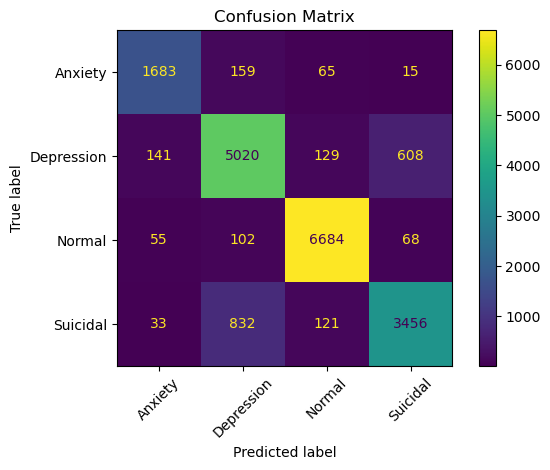

In [32]:
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
# disp.plot(cmap='Blues', xticks_rotation=45)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

#### **Pickle the Neural Network model**
This way the model may be used in other places, whether is our simple website or somewhere else.


In [34]:
model.save("neural_network.model.h5")
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

# Accessing the models from a website
The following code block is the backend API used by our website.  The frontend calls the `classify_mental_health` function and passes in its choice of classifier.

#### Limitations
This code was designed to work with the Streamlit library and cloud service.  This means it has to function in a fairly stateless manner.  As such, we have to load the models on every query.  For a more permenant website or heavier duty usage, we would want to make a dedicated backend application that would keep the models resident in memory between calls.


Please refer to our website to see it in use: [Mental Health Classifier](https://info-629-mental-health-classifier.streamlit.app/)

In [35]:
# ----------------------------
# Import Classifier fucntions
# ----------------------------
import enum
import pickle
import tensorflow as tf

from sklearn.feature_extraction.text import CountVectorizer

class MentalHealthClassifiers(enum.Enum):
    NAIVE_BAYES = "Naive Bayes"
    NEURAL_NETWORK = "Neural Network"

class ClassifierLabels(enum.Enum):
    ANXIETY = "Anxiety"
    DEPRESSION = "Depression"
    NORMAL = "Normal"
    SUICIDAL = "Suicidal"
    ERROR = "ERROR"

def classify_mental_health(classifier: MentalHealthClassifiers, text: str) -> ClassifierLabels:
    if classifier == MentalHealthClassifiers.NAIVE_BAYES:
        return classify_naive_bayes(text)
    elif classifier == MentalHealthClassifiers.NEURAL_NETWORK:
        return classify_neural_network(text)
    else:
        return ClassifierLabels.ERROR
    
def classify_naive_bayes(text: str) -> ClassifierLabels:
    text = text.lower()
    
    # Load the pre‑trained Naive Bayes model
    with open('./naive_bayes/naive_bayes_model.pkl', 'rb') as file:
        nb_model = pickle.load(file)

    with open('./naive_bayes/count_vectorizer.pkl', 'rb') as file:
        vectorizer = pickle.load(file)
    
    query = [text]
    query_vector = vectorizer.transform(query)
    prediction = nb_model.predict(query_vector)
        
    return ClassifierLabels(prediction[0])

def classify_neural_network(text: str) -> ClassifierLabels:
    text = text.lower()

    # Load the pre-trained neural network model
    nn_model = tf.keras.models.load_model('./neural_network/neural_network.model.h5')

    # Load the corresponding CountVectorizer
    with open('./neural_network/vectorizer.pkl', 'rb') as file:
        vectorizer = pickle.load(file)

    with open('./neural_network/label_encoder.pkl', 'rb') as file:
        encoder = pickle.load(file)

    # Transform the input text
    query = [text]
    query_vector = vectorizer.transform(query).toarray()

    # Get prediction from the neural network model
    prediction = nn_model.predict(query_vector)

    # Map prediction to ClassifierLabels enum
    predicted_label = encoder.inverse_transform([prediction.argmax()])[0]
    return ClassifierLabels(predicted_label)


After constructing our classifiers, we used Streamlit library (and cloud hoster) to deploy the classifiers as an example website. You can view the application here: [Mental Health Classifier](https://info-629-mental-health-classifier.streamlit.app/)

**REFERENCES:**

**Datasets**:

Mukherjee, P. (n.d.). Mental Health Text Classication Datasets. Kaggle.

https://www.kaggle.com/datasets/priyangshumukherjee/mental-health-text-classification-dataset

Footsurebead. (n.d.). Mental Health Status Dataset. Kaggle.

https:///www.kaggle.com/datasets/footsurebead/mental-status


**Software and Libraries**

Abadi, M., et al. (2016). TensorFlow: A system for large-scale machine learning. Google Research.

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research.

McKinney, W. (2010). Data Structures for Statistical Computing in Python. Pandas Library.

Harris, C., et al. (2020). Array programming with NumPy. Nature.



**Tools**:

Streamlit. (2023). Streamlit Documentation. https://streamlit.io

GitHub. (2024). GitHub Documentation. https://github.com
